In [1]:
import numpy
from os.path import join
import matplotlib.pyplot as plt
import colorsys
import texplot

from freealg import AlgebraicForm
from freealg.distributions import \
    MarchenkoPastur, ChiralBlock, DeformedWigner, \
    DeformedMarchenkoPastur, CompoundFreePoisson, FreeLevy

plot_dir = './plots'

# Option 1. Marchenko-Pastur Model

* This has two sheets $s=2$ and one cut $k=1$.
* Corresponding compact geometry is a Riemann sphere $\mathbb{S}^2$.

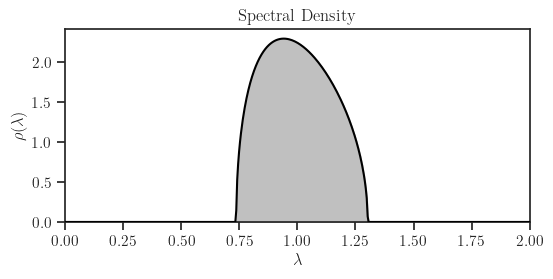

In [13]:
filename = 'mp'
title = 'Marchenko-Pastur Model'
sigma = 1.0
lam = 100 / 5000

mp = MarchenkoPastur(lam, sigma)
support = mp.support()
a1, b1 = support[0]

# Grid for MP
x_min, x_max = -0.5, 2.5
y_min, y_max = -1.0, 1.0

_ = mp.density(plot=True, latex=True, save=False)

# Option 2. Chiral Block

* This has two sheets $s=2$ and two cuts $k=2$.
* Corresponding compact geometry is a torus $\mathbb{T}^1$.

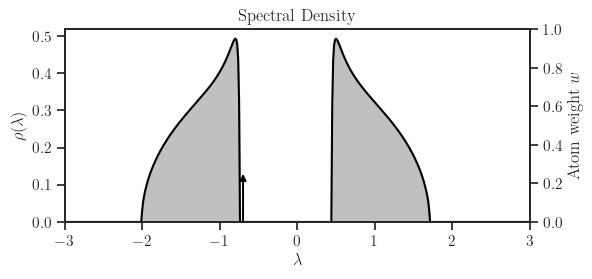

In [12]:
filename = 'cb'
title = 'Chiral Block Model'
alpha = 0.40
beta = -0.70
c = 0.6

cb = ChiralBlock(alpha, beta, c)

# Support
support = cb.support()

# Grid for bipartite
x_min, x_max = -3.0, 3.0
y_min, y_max = -2.0, 2.0

_ = cb.density(plot=True, latex=True, save=False)

# Option 3. Deformed Wigner Model

* This has three sheets $s=3$ and two cuts $k=2$.
* Corresponding compact geometry is still a Riemann sphere $\mathbb{S}^2$.

[(-2.6664926899770567, -0.7147737555874724), (0.8478632229082883, 4.283403222656241)]


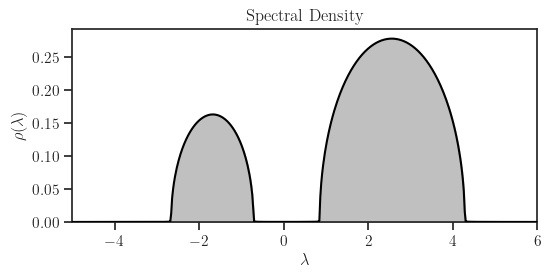

In [12]:
filename = 'dwg'
title = 'Deformed Wigner Model'
sigma = 1.0
t1 = -1.5
t2 = 2.5
w1 = 0.25

dwg = DeformedWigner(t=[t1, t2], w=[w1, 1-w1], sigma=sigma)

# Support
support = dwg.support()
print(support)

# Grid
x_min = numpy.floor(min(a for a, b in support) - 1.0)
x_max = numpy.ceil(max(b for a, b in support) + 1.0)
y_min, y_max = -3.0, 3.0

_ = dwg.density(plot=True, latex=True, save=False)

# Option 4. Deformed Marchenko-Pastur Model

* This has three sheets $s=3$ and two cuts $k=2$.
* Corresponding compact geometry is still a Riemann sphere $\mathbb{S}^2$.

[(1.271942644768898, 2.796717409578293), (4.465954791747979, 6.910028011047688)]


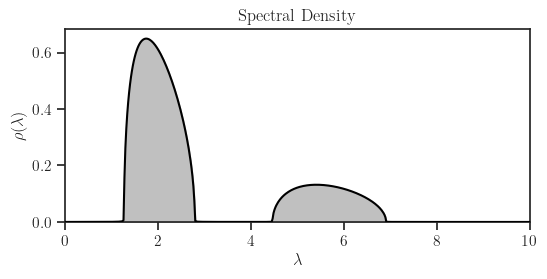

In [10]:
filename = 'dmp'
title = 'Deformed Marchenko-Pastur Model'
c = 0.05
t1 = 2.0
t2 = 5.5
w1 = 0.75

dmp = DeformedMarchenkoPastur(t=[t1, t2], w=[w1, 1-w1], c=c)

# Support
support = dmp.support()
print(support)

# Grid
x_min = numpy.floor(min(a for a, b in support) - 2.0)
x_max = numpy.ceil(max(b for a, b in support) + 2.0)
y_min, y_max = -3.0, 3.0

_ = dmp.density(plot=True, latex=True, save=False)

# Option 5. Compound Free Poisson Model

* This has three sheets $s=3$ and two cuts $k=2$.

[(0.9984996249062267, 3.13165791447862), (4.157389347336835, 7.597674418604652)]


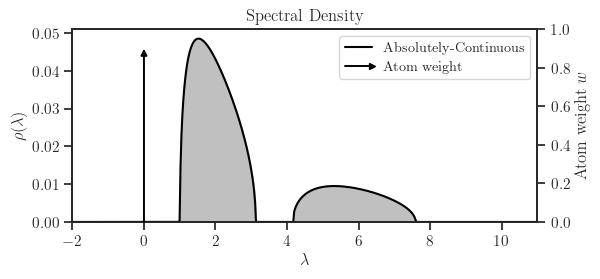

In [9]:
filename = 'cfp'
title = 'Compound Free Poisson'

lam = 0.1
t1 = 2.0
t2 = 5.5
w1 = 0.75

cfp = CompoundFreePoisson(t=[t1, t2], w=[w1, 1-w1], lam=lam)

# Support
support = cfp.support()
print(support)

# Grid
x_min = numpy.floor(min(a for a, b in support) - 1.0)
x_max = numpy.ceil(max(b for a, b in support) + 1.0)
y_min, y_max = -3.0, 3.0

_ = cfp.density(plot=True, latex=True, save=False)

# Option 6. Free Levy Model

* This has three sheets $s=3$ and two cuts $k=2$.

[(-1.938184546136533, 3.5198799699925), (4.3766691672918245, 7.750937734433611)]


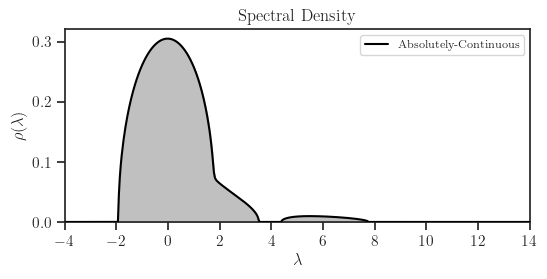

In [2]:
filename = 'fl'
title = 'Free Levy Model'

lam = 0.1
t1 = 2.0
t2 = 5.5
w1 = 0.75

fl = FreeLevy(t=[t1, t2], w=[w1, 1-w1], lam=lam, a=0, sigma=1.0)

# Support
support = fl.support()
print(support)

# Grid
x_min = numpy.floor(min(a for a, b in support) - 1.0)
x_max = numpy.ceil(max(b for a, b in support) + 1.0)
y_min, y_max = -3.0, 3.0

_ = fl.density(plot=True, latex=True, save=False)

Plot saved to "/home/sia/work/github/freealg/notebooks/aa.svg".


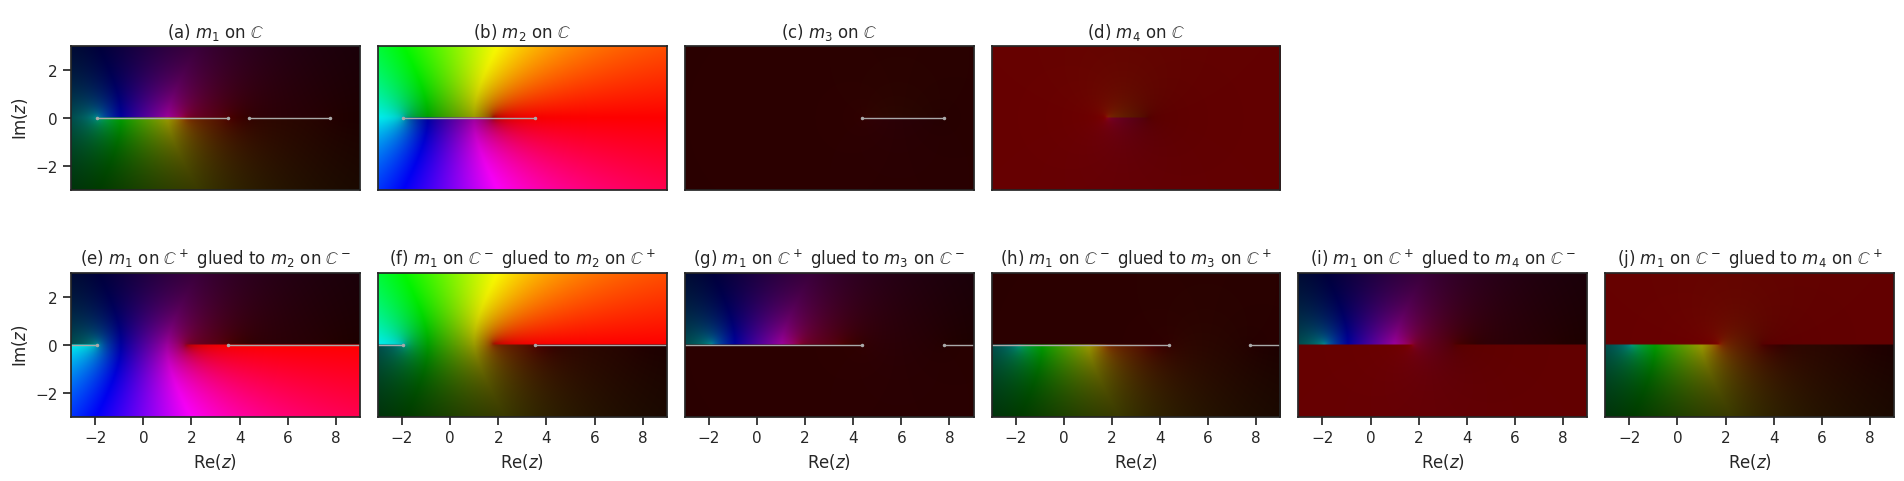

In [3]:
x = numpy.linspace(x_min, x_max, 200)
y = numpy.linspace(y_min, y_max, 200)
fl.plot_branches(x, y, tile_mix=0.0, save=False)

In [12]:
import numpy as np
from freealg.visualization._sheets_util import build_sheets_from_roots

# grid (same as plot_branches)
X, Y = np.meshgrid(x, y)
z = X + 1j * Y
ny, nx = z.shape

# physical sheet (your stieltjes)
m1 = fl.stieltjes(z)

# ALL roots, FLAT shape (ny*nx, s)
roots_flat = fl.roots(z.ravel())          # (ny*nx, 4)

# build tracked sheets
(sheets, idxs) = build_sheets_from_roots(z, roots_flat, m1)

# sheets is a list: sheets[k] is (ny, nx)
S = np.stack([np.asarray(M) for M in sheets], axis=0)  # (s, ny, nx)

# pick rows just above/below the y=0 "band" used internally
ycol = np.imag(z[:, 0])
y_unique = np.unique(ycol)
dy = float(np.min(np.diff(y_unique))) if y_unique.size >= 2 else 0.0
eps_y = 1.1 * dy

i_up = int(np.where(ycol >  eps_y)[0][0])
i_dn = int(np.where(ycol < -eps_y)[0][-1])

xline = np.real(z[0, :])

def jump_range(J, thr=1e-2):
    mask = (J > thr) & np.isfinite(J)
    if not np.any(mask):
        return None
    return (float(xline[mask].min()), float(xline[mask].max()))

for k in range(S.shape[0]):
    J = np.abs(S[k, i_up, :] - S[k, i_dn, :])
    print(f"sheet {k} (seed root idx {idxs[k]}) jump range:", jump_range(J, thr=1e-2))


sheet 0 (seed root idx 0) jump range: (-3.0, 7.673366834170853)
sheet 1 (seed root idx 1) jump range: (-3.0, 9.0)
sheet 2 (seed root idx 2) jump range: (1.341708542713568, 3.633165829145728)
sheet 3 (seed root idx 3) jump range: (4.417085427135678, 7.673366834170853)


In [14]:
import numpy as np

a, b = support[0]
mask = (xline >= a) & (xline <= b)

# glue score between sheet0 and sheet k: m1+ ~ mk- and m1- ~ mk+
def glue_score(k):
    return (np.abs(S[0, i_up, :] - S[k, i_dn, :]) +
            np.abs(S[0, i_dn, :] - S[k, i_up, :]))

D = np.vstack([glue_score(1), glue_score(2), glue_score(3)])  # k=1..3
K = np.argmin(D, axis=0) + 1  # partner index in {1,2,3}

# compress into segments on support[0]
idx = np.where(mask)[0]
segs = []
start = idx[0]
for t in range(1, idx.size):
    if K[idx[t]] != K[idx[t-1]]:
        segs.append((float(xline[start]), float(xline[idx[t-1]]), int(K[idx[t-1]])))
        start = idx[t]
segs.append((float(xline[start]), float(xline[idx[-1]]), int(K[idx[-1]])))

print("m1 partner segments on support[0] (a,b,k):")
for a0, b0, k in segs:
    print(a0, b0, k)


m1 partner segments on support[0] (a,b,k):
-1.914572864321608 1.7035175879396984 1
1.7638190954773867 3.5125628140703515 2
